# Multi-Asset Portfolio Optimisation Across Economic Regimes

In [1]:
import logging
import warnings
from pathlib import Path

import pandas as pd

import portfolio_opt as po

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

config = po.BacktestConfig()
config

BacktestConfig(trading_days=252, lookback_years=5, subperiod_length_years=5, date_column='Dates', date_format='%d.%m.%Y', risk_free_col=None, hrp_max_k=10)

## 1. Data

The pipeline accepts any daily **index-level** dataset: a date column plus one
numeric column per series, with the risk-free instrument as the last column (or
named explicitly via `config.risk_free_col`). The loader sorts the index,
rejects duplicate dates and non-numeric columns, and parses dates without the
deprecated `date_parser` argument.

In [2]:
real_path = Path("data/Indices.xlsx")

if real_path.exists():
    data = po.load_index_data(real_path, config=config)
    data_source = "private dataset (data/Indices.xlsx)"
else:
    data = po.generate_synthetic_indices(seed=42)
    data_source = "synthetic dataset (private data not found - see portfolio_opt/synthetic.py)"

assets, risk_free = po.split_assets_risk_free(data, config=config)

print(f"Source        : {data_source}")
print(f"Span          : {data.index.min().date()} to {data.index.max().date()}")
print(f"Observations  : {len(data):,} trading days")
print(f"Assets        : {list(assets.columns)}")
print(f"Risk-free     : {risk_free.name if risk_free is not None else 'none (rf = 0)'}")
data.head()

INFO | Loaded 6521 rows x 8 columns from Indices.xlsx (1999-01-01 to 2023-12-29).
INFO | Risk-free instrument taken as last column: 'T-Bills'.


Source        : private dataset (data/Indices.xlsx)
Span          : 1999-01-01 to 2023-12-29
Observations  : 6,521 trading days
Assets        : ['DM Equity', 'EM Equity', 'IG Bonds', 'HY Bonds', 'Commodities', 'Private Equity', 'Real Estate']
Risk-free     : T-Bills


,DM Equity,EM Equity,IG Bonds,HY Bonds,Commodities,Private Equity,Real Estate,T-Bills
Dates,,,,,,,,
1999-01-01,1149.95,298.97,225.2140,278.3153,112.796,752.39,918.53,133.95
1999-01-04,1161.52,303.71,226.2967,279.5403,113.411,762.49,924.07,133.96
1999-01-05,1173.34,306.69,226.0042,280.7028,113.106,761.81,924.35,133.97
1999-01-06,1195.45,313.76,225.7163,280.8286,115.245,775.85,933.88,134.00
1999-01-07,1191.63,316.96,225.4935,279.7346,115.487,780.30,945.05,134.04


## 2. Descriptive statistics by sub-period

Annualised return and volatility per asset over equal-length calendar blocks.
The blocks are **derived from the data span** rather than hard-coded, so the
table adapts to whatever period the dataset covers. Returns are computed within
each block (so no observation outside a block contributes to it).

In [3]:
subperiods = po.generate_subperiods(data, config=config)
subperiod_table = po.subperiod_descriptive_table(
    data, subperiods, trading_days=config.trading_days
)
subperiod_table

INFO | Generated 6 descriptive sub-periods.


DM Equity            EM Equity            IG Bonds            HY Bonds            Commodities            Private Equity            Real Estate  \
             Return Volatility    Return Volatility   Return Volatility   Return Volatility      Return Volatility         Return Volatility      Return   
1999-2003     -0.74      15.95      8.97      16.57     5.26       5.39     8.87       4.46       14.87      13.41           8.49      18.74       11.07   
2004-2008     -0.81      17.19      7.50      23.33     4.90       5.90     0.26       5.49        2.08      19.28          -7.15      21.59        3.98   
2009-2013     12.93      17.33     12.85      19.33     3.84       5.19    17.24       5.00        2.93      17.20          24.46      25.02       16.49   
2014-2018      3.04      10.96      0.26      14.01     1.15       4.62     3.23       3.51       -8.14      12.38           3.60      13.38        5.51   
2019-2023     11.67      17.91      2.61      17.21    -0.15       5.63     3.93       6.66        8.03      15.97          19.95      25.75        5.57   
Overall        5.21      16.07      6.45      18.35     3.00       5.36     6.70       5.14        3.95      15.84           9.86      21.38        8.52   

                     T-Bills             
          Volatility  Return Volatility  
1999-2003      10.24    3.49       0.55  
2004-2008      20.45    3.28       0.33  
2009-2013      20.43    0.22       0.05  
2014-2018      10.49    0.68       0.08  
2019-2023      19.73    1.86       0.19  
Overall        16.96    1.90       0.31

## 3. Descriptive statistics by economic regime

The regime calendar is **pre-defined and exogenous**. When the dataset only
covers part of it, each interval is clipped to the available span and regimes
with no overlapping data are dropped automatically — so a partial dataset never
breaks the analysis. Daily returns are pooled within each regime to describe
behaviour *conditional* on that state.

In [4]:
regimes = po.clip_regimes_to_data(po.DEFAULT_REGIMES, data)
regime_table = po.regime_descriptive_table(
    data, regimes, trading_days=config.trading_days
)
regime_table

DM Equity            EM Equity            IG Bonds            HY Bonds            Commodities            Private Equity             \
                   Return Volatility    Return Volatility   Return Volatility   Return Volatility      Return Volatility         Return Volatility   
Expansion           11.53      10.94     18.31      15.73     2.64       4.96     6.54       3.15       15.64      14.32          21.86      15.47   
Recession           -7.95      29.93      1.57      31.49     5.71       6.74     3.81      10.50      -18.41      21.92         -22.75      40.12   
Recovery            14.28      15.42     21.27      16.24     7.70       5.61    16.97       4.57       12.29      16.37          27.75      20.01   
Stagflation        -20.71      20.62    -25.06      20.28    -3.10       7.12    -3.73       6.34       15.07      20.70         -30.39      26.21   
Moderate Growth      5.59      13.11     -2.77      15.32     2.48       4.61     6.62       4.06       -8.20      13.23          10.68      17.08   

                Real Estate            T-Bills             
                     Return Volatility  Return Volatility  
Expansion             17.10      11.18    2.94       0.43  
Recession            -12.97      35.24    2.05       0.38  
Recovery              23.57      15.17    1.42       0.16  
Stagflation          -21.19      18.62    1.92       0.25  
Moderate Growth        7.70      13.06    0.90       0.12

## 4. Correlation structure

Pairwise correlation of daily returns across the full sample (the risk-free
series is included here for context).

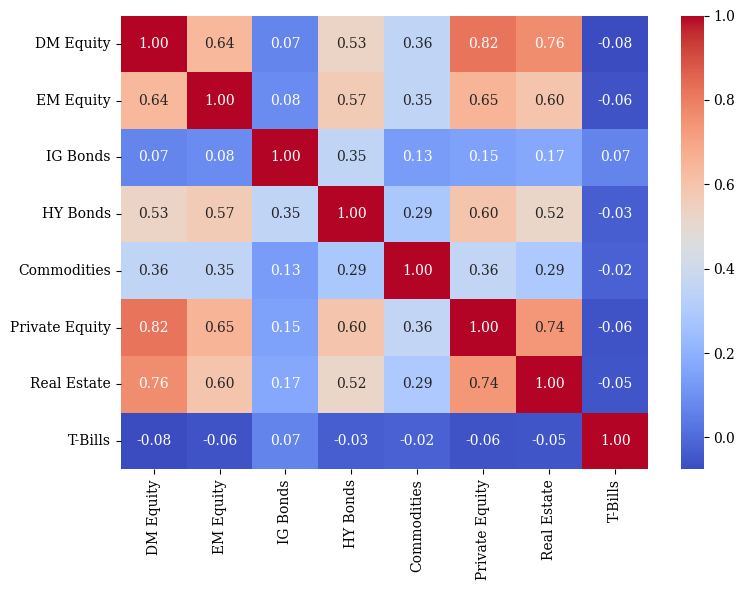

In [5]:
returns = data.pct_change().dropna()
_ = po.plot_correlation_heatmap(returns)  # auto-displayed inline

## 5. Rolling-window backtest

For each test year, the six portfolios are fit on the preceding five years of
daily returns and held fixed for the year. The first and last test years are
derived from the data span. Daily portfolio returns and excess returns (over
the daily risk-free rate) are recorded.

In [6]:
results = po.run_backtest(assets, risk_free, config=config)
combined_results = results.combined_results
print(f"Test years: {combined_results.index.min().date()} to {combined_results.index.max().date()}")
combined_results.tail()

INFO | Backtest complete: 20 test years.


Test years: 2004-01-02 to 2023-12-29


,EW_return,TANGENCY_return,MIN RISK_return,MDP_return,RP_return,HRP_return,EW_excess_return,TANGENCY_excess_return,MIN RISK_excess_return,MDP_excess_return,RP_excess_return,HRP_excess_return
Dates,,,,,,,,,,,,
2023-12-25,0.000090,-0.000005,0.000084,0.000161,0.000098,0.000080,0.000090,-0.000005,0.000084,0.000161,0.000098,0.000080
2023-12-26,0.003737,0.005466,0.001024,0.002463,0.002547,0.001654,0.003600,0.005329,0.000887,0.002326,0.002410,0.001517
2023-12-27,0.006478,0.004535,0.006110,0.006439,0.006148,0.005969,0.006295,0.004353,0.005927,0.006256,0.005966,0.005786
2023-12-28,0.002610,-0.002666,-0.000355,0.000650,0.001084,0.000296,0.002427,-0.002848,-0.000538,0.000467,0.000901,0.000114
2023-12-29,-0.004785,-0.009108,-0.002594,-0.003712,-0.003673,-0.002879,-0.005378,-0.009702,-0.003187,-0.004306,-0.004266,-0.003473


## 6. Allocations over time

Average allocation per asset across all rebalancing years (%). The full
year-by-year weights for every portfolio are available in
`results.weights_over_time`; the tangency portfolio is shown as an example.

In [9]:
display(results.average_weights)

print("\nExample - HRP weights by year:")
results.weights_over_time["HRP"].round(4)

,EW,TANGENCY,MIN RISK,MDP,RP,HRP
DM Equity,14.29,0.01,0.50,6.57,7.58,2.71
EM Equity,14.29,1.18,0.00,5.87,6.69,2.49
IG Bonds,14.29,17.37,42.35,56.90,36.73,44.09
HY Bonds,14.29,69.39,55.49,10.33,25.44,41.94
Commodities,14.29,4.98,1.21,13.20,9.93,3.69
Private Equity,14.29,3.26,0.00,1.80,5.82,1.71
Real Estate,14.29,3.83,0.44,5.33,7.82,3.37



Example - HRP weights by year:


,DM Equity,EM Equity,IG Bonds,HY Bonds,Commodities,Private Equity,Real Estate
2004,0.0296,0.0246,0.3225,0.4699,0.0621,0.0193,0.0719
2005,0.0217,0.0186,0.3024,0.5318,0.0630,0.0157,0.0468
2006,0.0249,0.0236,0.2874,0.5343,0.0589,0.0252,0.0457
2007,0.0408,0.0308,0.2271,0.5582,0.0427,0.0384,0.0621
2008,0.0466,0.0219,0.2136,0.6090,0.0374,0.0330,0.0385
2009,0.0216,0.0236,0.4667,0.4261,0.0257,0.0137,0.0228
2010,0.0181,0.0228,0.5236,0.3884,0.0218,0.0098,0.0156
2011,0.0167,0.0222,0.5423,0.3733,0.0218,0.0089,0.0147
2012,0.0149,0.0218,0.5798,0.3398,0.0221,0.0079,0.0137
2013,0.0150,0.0225,0.5903,0.3275,0.0222,0.0080,0.0144


## 7. Full-sample performance

Out-of-sample performance summary, one row per portfolio. "Sharpe Ratio" is a
geometric Sharpe: annualised geometric excess return divided by annualised
volatility.

In [10]:
summary = po.portfolio_summary_table(
    combined_results, results.port_types, trading_days=config.trading_days
)
summary

,Annual Mean Return (%),Annual Geometric Return (%),Annual Std Dev (%),Annual Excess Return (%),Sharpe Ratio,Maximum Drawdown (%),Cumulative Return (%)
EW,5.79,5.25,11.57,3.67,0.32,-55.13,187.44
TANGENCY,3.59,3.44,6.46,1.89,0.29,-37.77,100.96
MIN RISK,3.68,3.63,4.86,2.07,0.43,-34.08,108.54
MDP,3.45,3.29,6.50,1.73,0.27,-32.51,94.87
RP,4.41,4.22,7.36,2.65,0.36,-40.21,134.56
HRP,3.83,3.76,5.37,2.20,0.41,-34.46,113.98


## 8. Performance by economic regime

The same statistics, with daily backtest returns pooled within each regime.
*Caveat:* pooling non-contiguous intervals chains returns across calendar gaps,
so the regime-level maximum drawdown can show artificial moves at interval
seams; means and volatilities are unaffected.

In [11]:
regime_performance = po.regime_performance_table(
    combined_results, regimes, results.port_types, trading_days=config.trading_days
)
regime_performance

Annual Mean Return (%)  Annual Geometric Return (%)  Annual Std Dev (%)  Annual Excess Return (%)  Sharpe Ratio  \
Expansion       EW                         12.76                        13.29                7.46                     10.59          1.42   
                TANGENCY                    6.77                         6.93                3.89                      4.38          1.13   
                MIN RISK                    5.19                         5.27                3.34                      2.77          0.83   
                MDP                         7.48                         7.63                4.94                      5.07          1.03   
                RP                          8.83                         9.08                5.21                      6.48          1.25   
                HRP                         6.32                         6.44                3.86                      3.91          1.01   
Recession       EW                         -4.59                        -7.55               25.46                     -8.30         -0.33   
                TANGENCY                   -8.49                        -8.88               12.71                     -9.60         -0.76   
                MIN RISK                   -1.51                        -2.05               10.53                     -2.82         -0.27   
                MDP                         0.16                        -0.77               13.60                     -1.56         -0.11   
                RP                         -2.27                        -3.53               16.20                     -4.30         -0.27   
                HRP                        -1.09                        -1.75               11.65                     -2.53         -0.22   
Recovery        EW                         20.02                        21.29               11.95                     19.71          1.65   
                TANGENCY                   10.34                        10.54                7.88                      9.10          1.15   
                MIN RISK                   12.06                        12.69                4.58                     11.21          2.45   
                MDP                        11.10                        11.52                6.30                     10.06          1.60   
                RP                         14.40                        15.20                7.10                     13.69          1.93   
                HRP                        12.44                        13.11                4.97                     11.63          2.34   
Stagflation     EW                        -15.00                       -14.65               12.90                    -16.32         -1.26   
                TANGENCY                  -14.24                       -13.73               10.23                    -15.42         -1.51   
                MIN RISK                   -9.93                        -9.62                6.09                    -11.39         -1.87   
                MDP                        -9.58                        -9.42                7.93                    -11.20         -1.41   
                RP                        -11.47                       -11.16                8.56                    -12.91         -1.51   
                HRP                       -10.70                       -10.34                6.60                    -12.10         -1.83   
Moderate Growth EW                          3.12                         2.75                9.02                      1.82          0.20   
                TANGENCY                    5.52                         5.57                4.48                      4.61          1.03   
                MIN RISK                    4.26                         4.28                3.64                      3.34          0.92   
                MDP                         1.69                         1.58 

## 9. Average allocation by model

Donut charts of the average weights, with a shared colour per asset.

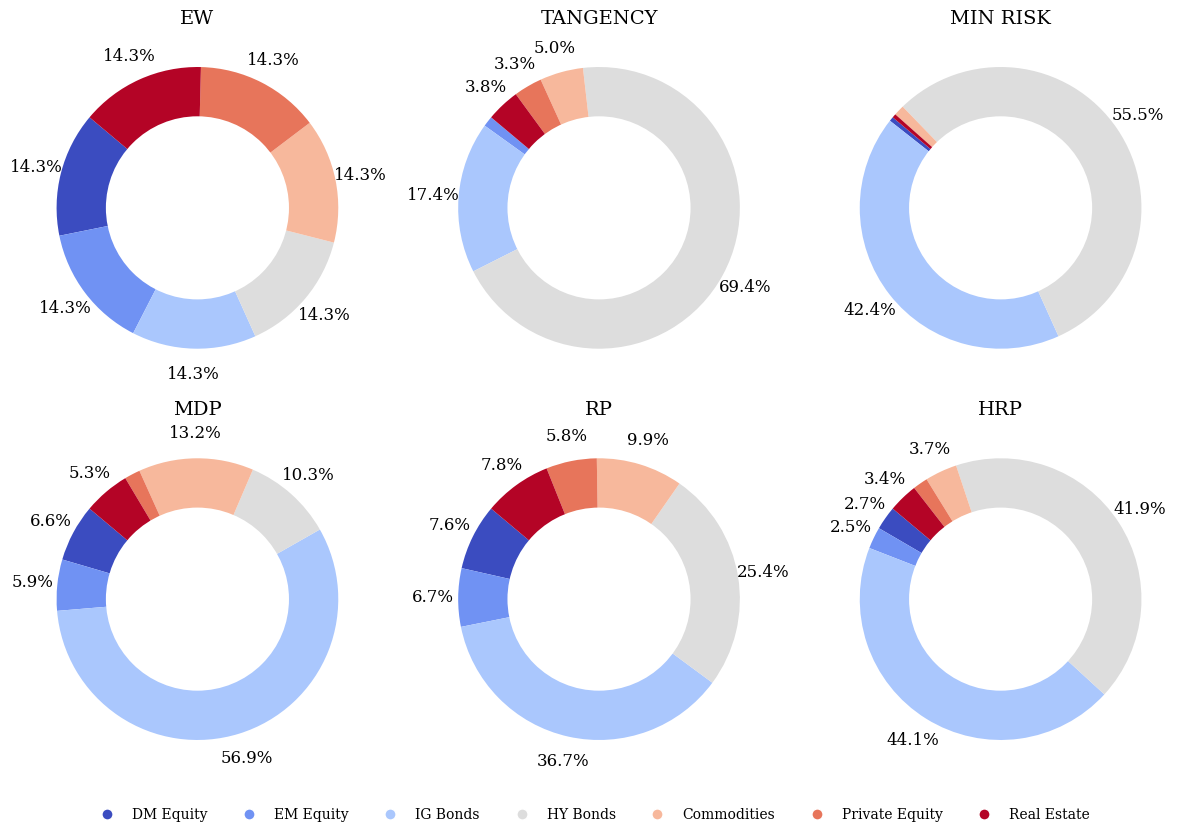

In [12]:
_ = po.plot_weight_donuts(results.average_weights, results.port_types)  # auto-displayed inline